Dataset shape: (150, 4)

K    CV Accuracy
1    0.9417
2    0.9583
3    0.9583
4    0.9583
5    0.9667
6    0.9667
7    0.9583
8    0.9583
9    0.9583
10   0.9667
11   0.9583
12   0.9667
13   0.9500
14   0.9583
15   0.9500

Best value of K: 5

Test Accuracy: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

New flower [5.9, 3.0, 5.1, 1.8] -> virginica


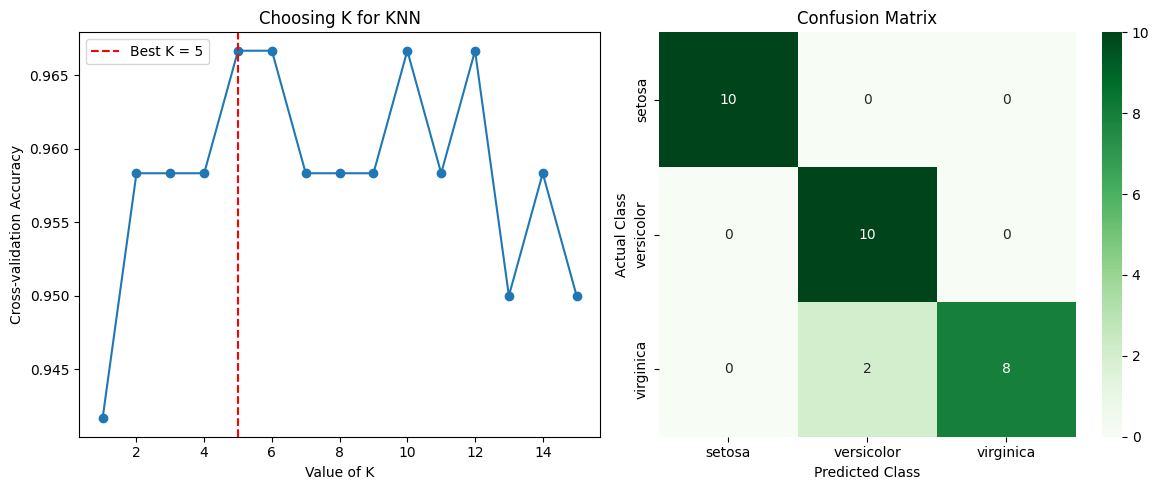

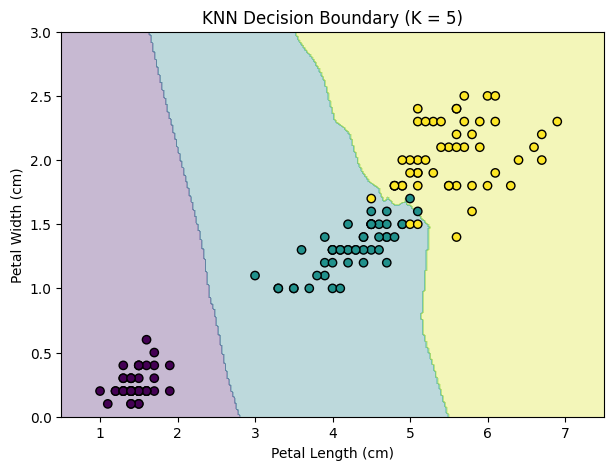

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report

iris = load_iris()
X, y = iris.data, iris.target
print("Dataset shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

k_values = range(1, 16)
cv_scores = []
print("\nK    CV Accuracy")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train_s, y_train, cv=5).mean()
    cv_scores.append(score)
    print(f"{k:<4} {score:.4f}")

best_k = k_values[int(np.argmax(cv_scores))]
print("\nBest value of K:", best_k)

knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train_s, y_train)
y_pred = knn.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("\nTest Accuracy:", round(acc, 4))
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

new_flower = scaler.transform([[5.9, 3.0, 5.1, 1.8]])
print("New flower [5.9, 3.0, 5.1, 1.8] ->",
      iris.target_names[knn.predict(new_flower)[0]])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(k_values, cv_scores, marker='o')
ax[0].axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
ax[0].set_xlabel("Value of K")
ax[0].set_ylabel("Cross-validation Accuracy")
ax[0].set_title("Choosing K for KNN")
ax[0].legend()
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=iris.target_names, yticklabels=iris.target_names)
ax[1].set_xlabel("Predicted Class")
ax[1].set_ylabel("Actual Class")
ax[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

X2 = X[:, 2:4]
knn2 = KNeighborsClassifier(n_neighbors=best_k).fit(X2, y)
xx, yy = np.meshgrid(np.linspace(0.5, 7.5, 300), np.linspace(0, 3, 300))
Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X2[:, 0], X2[:, 1], c=y, edgecolor='k', cmap='viridis')
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title(f"KNN Decision Boundary (K = {best_k})")
plt.show()
